# **Box Plots**


## Objectives


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [4]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-results-public.sqlite.5’

survey-results-publ 100%[===================>] 201.62M  7.26MB/s    in 35s     
2026-09-06 13:19:48 (5.70 MB/s) - ‘survey-results-public.sqlite.5’ saved [211415040/211415040]


#### 2. Connect to the Database


**Install the needed libraries**


In [3]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 148.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 175.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]


In [5]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 176.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 168.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 81.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 177.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


In [6]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.

In [9]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Basic SQL Queries


#### Count the Number of Rows in the Table


In [10]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437

#### List All Tables


In [11]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Group Data by Age


In [12]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568

## Visualizing Data


### Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


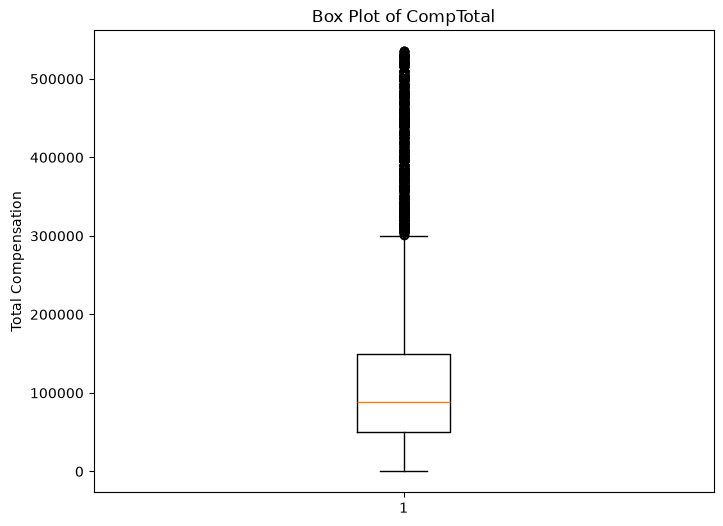

In [18]:
QUERY = """
SELECT CompTotal
FROM main
WHERE CompTotal IS NOT NULL
"""

df_comp = pd.read_sql_query(QUERY, conn)
df_comp["CompTotal"] = pd.to_numeric(df_comp["CompTotal"], errors="coerce")
df_comp = df_comp.dropna(subset=["CompTotal"])

Q1 = df_comp["CompTotal"].quantile(0.25)
Q3 = df_comp["CompTotal"].quantile(0.75)
IQR = Q3 - Q1

df_clean = df_comp[
    df_comp["CompTotal"].between(Q1 - 1.5*IQR, Q3 + 1.5*IQR)
]

plt.figure(figsize=(8, 6))
plt.boxplot(df_clean["CompTotal"], orientation="vertical")
plt.ylabel("Total Compensation")
plt.title("Box Plot of CompTotal")
plt.show()

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


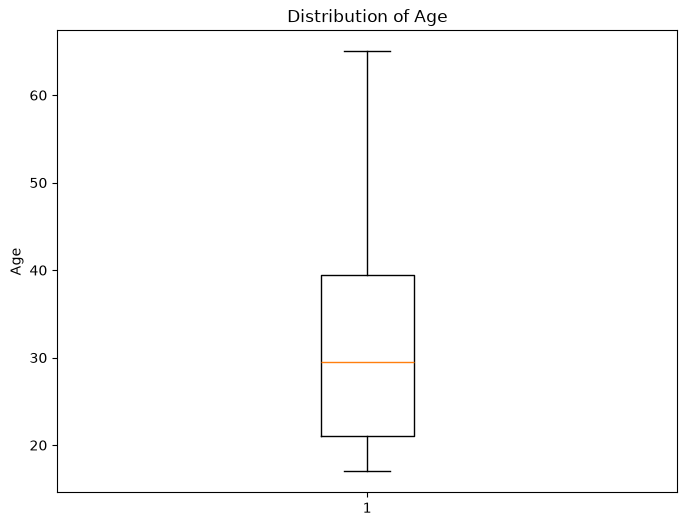

In [19]:
# Load Age column
QUERY = "SELECT Age FROM main WHERE Age IS NOT NULL"
df_age = pd.read_sql_query(QUERY, conn)

# Convert Age groups into numerical values
age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 65,
    "Prefer not to say": None
}

df_age["Age_numeric"] = df_age["Age"].map(age_mapping)

# Remove missing values
df_age = df_age.dropna(subset=["Age_numeric"])

# Create box plot
plt.figure(figsize=(8, 6))
plt.boxplot(df_age["Age_numeric"], showfliers=True)

plt.ylabel("Age")
plt.title("Distribution of Age")
plt.show()

### Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


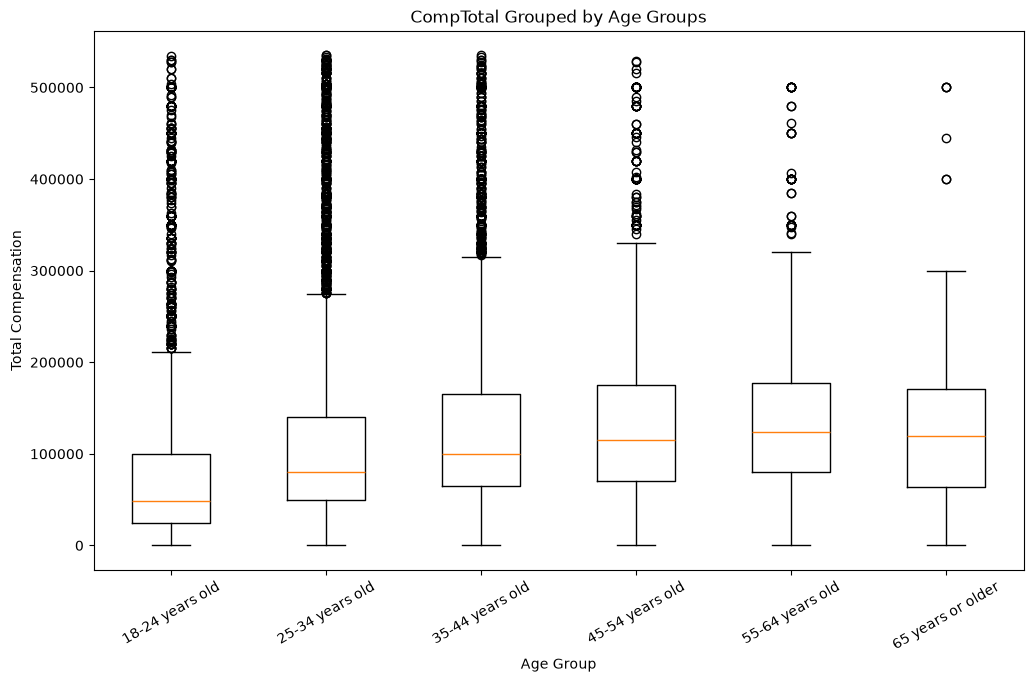

In [20]:
QUERY = "SELECT Age, CompTotal FROM main WHERE Age IS NOT NULL AND CompTotal IS NOT NULL"
df = pd.read_sql_query(QUERY, conn)
df["CompTotal"] = pd.to_numeric(df["CompTotal"], errors="coerce")
df = df.dropna(subset=["CompTotal"])

age_groups = ["18-24 years old", "25-34 years old", "35-44 years old",
              "45-54 years old", "55-64 years old", "65 years or older"]
Q1 = df["CompTotal"].quantile(0.25)
Q3 = df["CompTotal"].quantile(0.75)
IQR = Q3 - Q1

df_clean = df[df["CompTotal"].between(Q1 - 1.5*IQR, Q3 + 1.5*IQR)]

data = [df_clean.loc[df_clean["Age"] == age, "CompTotal"] for age in age_groups]
data = [x for x in data if len(x) > 0]
labels = [age for age in age_groups if len(df.loc[df["Age"] == age, "CompTotal"]) > 0]

plt.figure(figsize=(12, 7))
plt.boxplot(data, tick_labels=labels, showfliers=True)
plt.xlabel("Age Group")
plt.ylabel("Total Compensation")
plt.title("CompTotal Grouped by Age Groups")
plt.xticks(rotation=30)
plt.show()


**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


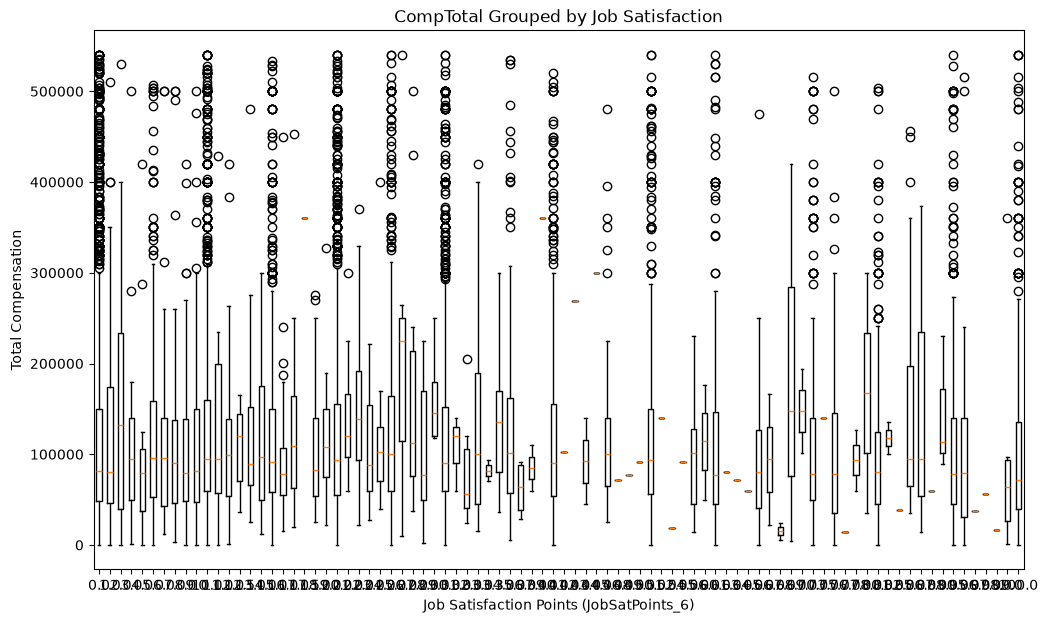

In [24]:
df["CompTotal"] = pd.to_numeric(df["CompTotal"], errors="coerce")
df["JobSatPoints_6"] = pd.to_numeric(df["JobSatPoints_6"], errors="coerce")

Q1 = df["CompTotal"].quantile(0.25)
Q3 = df["CompTotal"].quantile(0.75)
IQR = Q3 - Q1

df = df[df["CompTotal"].between(Q1 - 1.5*IQR, Q3 + 1.5*IQR)]

df = df.dropna()

groups = sorted(df["JobSatPoints_6"].unique())
data = [df.loc[df["JobSatPoints_6"] == s, "CompTotal"] for s in groups]

plt.figure(figsize=(12, 7))
plt.boxplot(data, tick_labels=[str(s) for s in groups], showfliers=True)
plt.xlabel("Job Satisfaction Points (JobSatPoints_6)")
plt.ylabel("Total Compensation")
plt.title("CompTotal Grouped by Job Satisfaction")
plt.show()

### Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


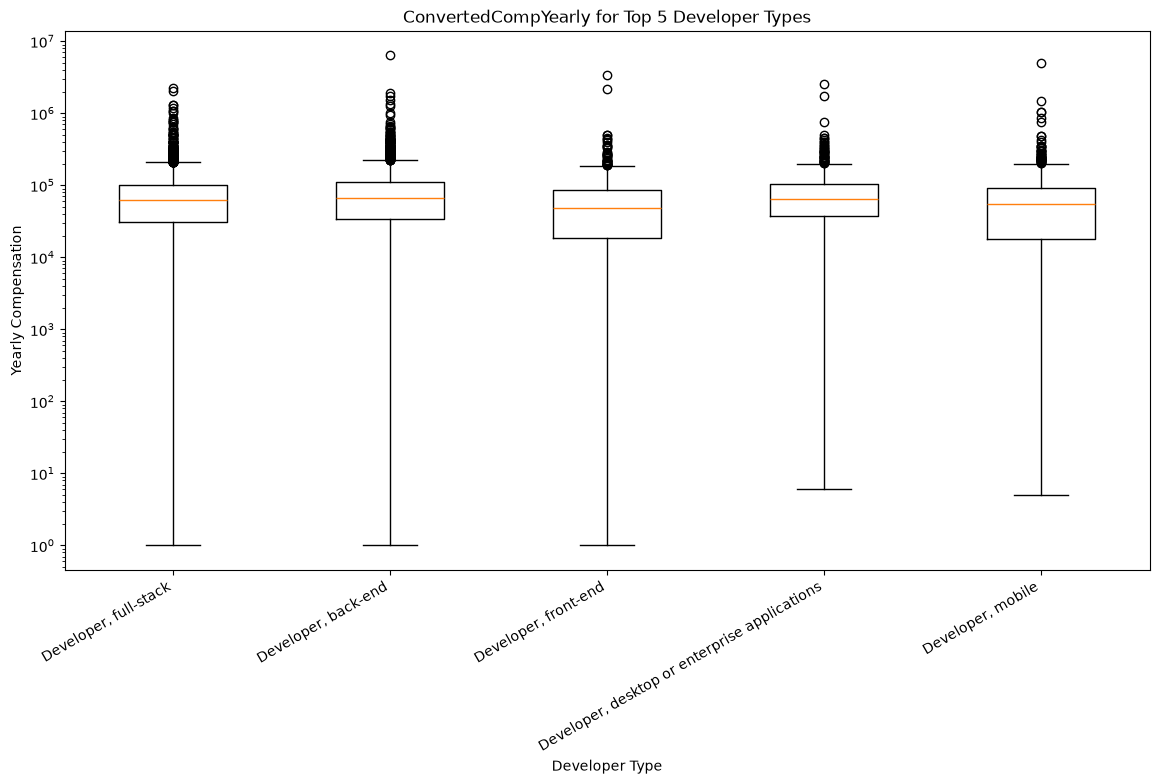

In [27]:
QUERY = "SELECT ConvertedCompYearly, DevType FROM main WHERE ConvertedCompYearly IS NOT NULL AND DevType IS NOT NULL"
df = pd.read_sql_query(QUERY, conn)
df["ConvertedCompYearly"] = pd.to_numeric(df["ConvertedCompYearly"], errors="coerce")
df = df.dropna(subset=["ConvertedCompYearly"])

top5 = df["DevType"].value_counts().head(5).index
data, labels = [], []
for dev in top5:
    values = df.loc[df["DevType"] == dev, "ConvertedCompYearly"]
    if len(values) > 0:
        data.append(values)
        labels.append(dev)

plt.figure(figsize=(14, 7))
plt.boxplot(data, tick_labels=labels, showfliers=True)
plt.xlabel("Developer Type")
plt.ylabel("Yearly Compensation")
plt.title("ConvertedCompYearly for Top 5 Developer Types")
plt.xticks(rotation=30, ha="right")
plt.yscale('log')
plt.show()

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


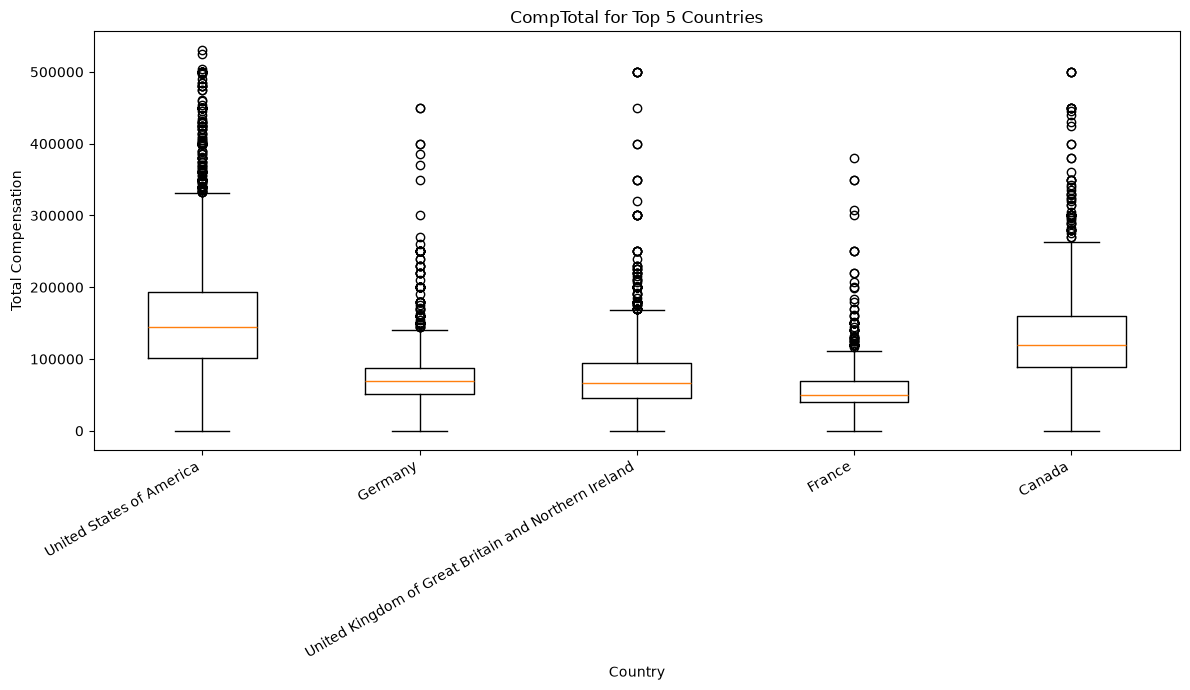

In [28]:
QUERY = """
SELECT CompTotal, Country
FROM main
WHERE CompTotal IS NOT NULL AND Country IS NOT NULL
"""

df = pd.read_sql_query(QUERY, conn)
df["CompTotal"] = pd.to_numeric(df["CompTotal"], errors="coerce")
df = df.dropna(subset=["CompTotal"])

Q1 = df["CompTotal"].quantile(0.25)
Q3 = df["CompTotal"].quantile(0.75)
IQR = Q3 - Q1

df = df[df["CompTotal"].between(Q1 - 1.5*IQR, Q3 + 1.5*IQR)]

top5 = df["Country"].value_counts().head(5)
data = [df.loc[df["Country"] == c, "CompTotal"] for c in top5.index]

plt.figure(figsize=(12, 7))
plt.boxplot(data, tick_labels=top5.index, showfliers=True)
plt.xlabel("Country")
plt.ylabel("Total Compensation")
plt.title("CompTotal for Top 5 Countries")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


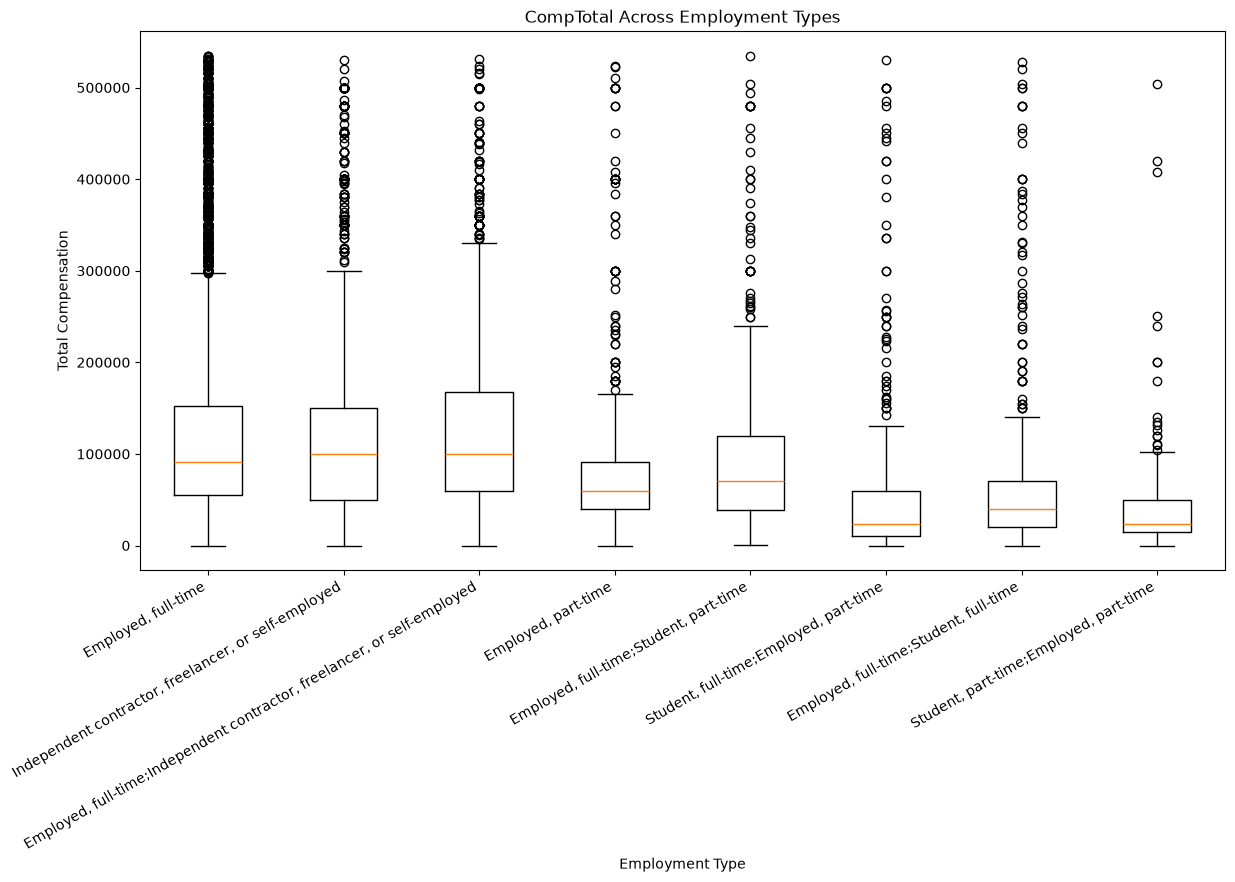

In [29]:
QUERY = "SELECT CompTotal, Employment FROM main WHERE CompTotal IS NOT NULL AND Employment IS NOT NULL"
df = pd.read_sql_query(QUERY, conn)
df["CompTotal"] = pd.to_numeric(df["CompTotal"], errors="coerce")
df = df.dropna(subset=["CompTotal"])
Q1 = df["CompTotal"].quantile(0.25)
Q3 = df["CompTotal"].quantile(0.75)
IQR = Q3 - Q1

df = df[df["CompTotal"].between(Q1 - 1.5*IQR, Q3 + 1.5*IQR)]
employment_types = df["Employment"].value_counts().head(8).index
data = [df.loc[df["Employment"] == emp, "CompTotal"] for emp in employment_types]

plt.figure(figsize=(14, 7))
plt.boxplot(data, tick_labels=list(employment_types), showfliers=True)
plt.xlabel("Employment Type")
plt.ylabel("Total Compensation")
plt.title("CompTotal Across Employment Types")
plt.xticks(rotation=30, ha="right")
plt.show()

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


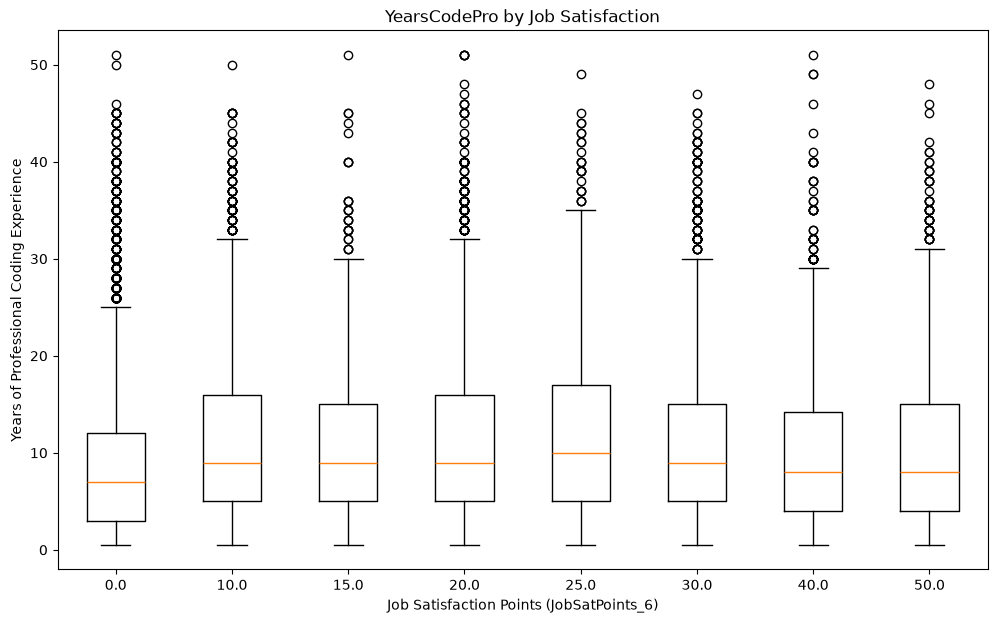

In [33]:
QUERY = "SELECT YearsCodePro, JobSatPoints_6 FROM main WHERE YearsCodePro IS NOT NULL AND JobSatPoints_6 IS NOT NULL"
df = pd.read_sql_query(QUERY, conn)
df["JobSatPoints_6"] = pd.to_numeric(df["JobSatPoints_6"], errors="coerce")
df["YearsCodePro_num"] = (
    df["YearsCodePro"]
    .replace({"Less than 1 year": 0.5, "More than 50 years": 51})
    .pipe(pd.to_numeric, errors="coerce")
)
df = df.dropna(subset=["YearsCodePro_num", "JobSatPoints_6"])

# Use the most common satisfaction levels to keep the comparison readable.
levels = df["JobSatPoints_6"].value_counts().head(8).index.sort_values()
data = [df.loc[df["JobSatPoints_6"] == level, "YearsCodePro_num"] for level in levels]

plt.figure(figsize=(12, 7))
plt.boxplot(data, tick_labels=[str(x) for x in levels], showfliers=True)
plt.xlabel("Job Satisfaction Points (JobSatPoints_6)")
plt.ylabel("Years of Professional Coding Experience")
plt.title("YearsCodePro by Job Satisfaction")
plt.show()


### Close the Database Connection


In [34]:
conn.close()

## Summary


- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.
